# Entrovia POC - Mapping Hidden Fragility in a Global Supply Chain Network

This notebook is a small proof of concept for **Entrovia**, a supply chain analytics project that uses **information theory** and **network analysis** to detect hidden fragility in complex trade networks.

The core idea is simple:

- represent a supply chain as a **directed weighted graph**
- measure how **concentrated** or **diversified** dependencies are
- simulate a shock
- observe which countries or nodes are structurally exposed

This first notebook is intentionally small and synthetic. It is not meant to be a realistic global trade model yet. Its purpose is to introduce the theory, the data model, and the first analytical building blocks that will later become the full codebase.

## Theory

We model a supply chain network as a directed graph:

- each **node** is a country or supply-chain actor
- each **edge** is a trade or dependency relationship
- each edge has a **weight**, representing trade volume or dependency strength

If many imports come from only one supplier, the system is structurally fragile.
If imports are distributed across many suppliers, the system is more diversified.

### Shannon entropy

To quantify diversification, we use **Shannon entropy**:

$$H(X) = - \sum_i p_i \log_2(p_i)$$

where $p_i$ is the share of imports coming from supplier $i$.

Interpretation:

- **low entropy** → concentrated dependence
- **high entropy** → diversified sourcing

Because entropy depends on the number of suppliers, we also use **normalized entropy**:

$$H_{norm}(X) = \frac{H(X)}{\log_2(n)}$$

where $n$ is the number of suppliers.

This gives a score between 0 and 1:

- **0** = fully concentrated
- **1** = perfectly balanced across suppliers

### What this notebook demonstrates

This notebook covers five basic steps:

1. Create a toy global trade dataset
2. Build a directed weighted graph
3. Compute import/export entropy
4. Visualize structural dependence
5. Simulate a disruption and compare the network before and after

Later, the project can grow toward:

- firm-level supplier graphs
- time-varying networks
- logistics routes and ports
- scenario simulation
- multi-tier supply-chain fragility analysis

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Step 1 - Create a small synthetic trade dataset

For this proof of concept, we use a simplified country-to-country trade network.
Each row is a directed supply relationship:

- `source` = exporter / upstream node
- `target` = importer / downstream node
- `commodity` = product family
- `trade_value` = edge weight

In [3]:
trade_data = [
    ("Taiwan", "Germany", "Semiconductors", 900),
    ("South Korea", "Germany", "Semiconductors", 500),
    ("China", "Germany", "Semiconductors", 300),
    ("USA", "Germany", "Semiconductors", 200),

    ("Taiwan", "USA", "Semiconductors", 1200),
    ("South Korea", "USA", "Semiconductors", 600),
    ("Japan", "USA", "Semiconductors", 400),
    ("China", "USA", "Semiconductors", 250),

    ("China", "Netherlands", "Battery Materials", 700),
    ("Chile", "China", "Copper", 800),
    ("Australia", "China", "Iron Ore", 1000),
    ("Brazil", "China", "Soy", 600),

    ("Germany", "France", "Automotive Parts", 500),
    ("Poland", "Germany", "Automotive Parts", 450),
    ("Czechia", "Germany", "Automotive Parts", 300),

    ("Mexico", "USA", "Automotive Parts", 900),
    ("Canada", "USA", "Automotive Parts", 500),

    ("Germany", "USA", "Machinery", 400),
    ("China", "India", "Electronics", 850),
    ("Vietnam", "USA", "Electronics", 500),
]

df = pd.DataFrame(trade_data, columns=["source", "target", "commodity", "trade_value"])
df

,source,target,commodity,trade_value
0,Taiwan,Germany,Semiconductors,900
1,South Korea,Germany,Semiconductors,500
2,China,Germany,Semiconductors,300
3,USA,Germany,Semiconductors,200
4,Taiwan,USA,Semiconductors,1200
5,South Korea,USA,Semiconductors,600
6,Japan,USA,Semiconductors,400
7,China,USA,Semiconductors,250
8,China,Netherlands,Battery Materials,700
9,Chile,China,Copper,800


## Step 2 — Define helper functions

These functions form the analytical core of the POC.

We implement:

- graph construction
- Shannon entropy
- normalized entropy
- import and export profiles
- a direct dependency metric
- a simple disruption scenario

In [4]:
def build_trade_graph(df: pd.DataFrame) -> nx.DiGraph:
    """
    Build a directed weighted graph from trade data.
    If multiple rows exist for the same source-target pair, aggregate them.
    """
    grouped = (
        df.groupby(["source", "target"], as_index=False)
        .agg(
            trade_value=("trade_value", "sum"),
            commodities=("commodity", lambda x: ", ".join(sorted(set(x))))
        )
    )

    G = nx.DiGraph()

    for _, row in grouped.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            weight=float(row["trade_value"]),
            commodities=row["commodities"],
        )

    return G


def shannon_entropy(weights) -> float:
    """
    Compute Shannon entropy from a list or array of positive weights.
    """
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()

    if total <= 0:
        return 0.0

    p = weights / total
    p = p[p > 0]

    return float(-np.sum(p * np.log2(p)))


def normalized_entropy(weights) -> float:
    """
    Normalize entropy to [0, 1] by dividing by log2(n).
    """
    weights = np.asarray(weights, dtype=float)
    n = len(weights)

    if n <= 1:
        return 0.0

    return float(shannon_entropy(weights) / np.log2(n))


def import_profile(G: nx.DiGraph, country: str) -> dict:
    """
    Compute import-side structure for one node.
    """
    in_edges = list(G.in_edges(country, data=True))
    weights = np.array([d["weight"] for _, _, d in in_edges], dtype=float)
    suppliers = [src for src, _, _ in in_edges]

    total_imports = float(weights.sum()) if len(weights) > 0 else 0.0

    return {
        "country": country,
        "n_suppliers": len(weights),
        "total_imports": total_imports,
        "import_entropy": shannon_entropy(weights),
        "normalized_import_entropy": normalized_entropy(weights),
        "top_supplier_share": float(weights.max() / total_imports) if total_imports > 0 and len(weights) > 0 else 0.0,
        "suppliers": suppliers,
    }


def export_profile(G: nx.DiGraph, country: str) -> dict:
    """
    Compute export-side structure for one node.
    """
    out_edges = list(G.out_edges(country, data=True))
    weights = np.array([d["weight"] for _, _, d in out_edges], dtype=float)
    customers = [tgt for _, tgt, _ in out_edges]

    total_exports = float(weights.sum()) if len(weights) > 0 else 0.0

    return {
        "country": country,
        "n_customers": len(weights),
        "total_exports": total_exports,
        "export_entropy": shannon_entropy(weights),
        "normalized_export_entropy": normalized_entropy(weights),
        "top_customer_share": float(weights.max() / total_exports) if total_exports > 0 and len(weights) > 0 else 0.0,
        "customers": customers,
    }


def compute_country_table(G: nx.DiGraph) -> pd.DataFrame:
    """
    Compute import/export structure for all nodes.
    """
    rows = []

    for node in G.nodes:
        imp = import_profile(G, node)
        exp = export_profile(G, node)

        rows.append({
            "country": node,
            "n_suppliers": imp["n_suppliers"],
            "total_imports": imp["total_imports"],
            "import_entropy": imp["import_entropy"],
            "normalized_import_entropy": imp["normalized_import_entropy"],
            "top_supplier_share": imp["top_supplier_share"],
            "n_customers": exp["n_customers"],
            "total_exports": exp["total_exports"],
            "export_entropy": exp["export_entropy"],
            "normalized_export_entropy": exp["normalized_export_entropy"],
            "top_customer_share": exp["top_customer_share"],
        })

    return pd.DataFrame(rows).sort_values("total_imports", ascending=False)


def direct_exporter_exposure(df: pd.DataFrame, exporter: str) -> pd.DataFrame:
    """
    For each importing country, compute dependency on one exporter.
    """
    total_imports = (
        df.groupby("target", as_index=False)["trade_value"]
        .sum()
        .rename(columns={"trade_value": "total_imports"})
    )

    from_exporter = (
        df[df["source"] == exporter]
        .groupby("target", as_index=False)["trade_value"]
        .sum()
        .rename(columns={"trade_value": "imports_from_exporter"})
    )

    exposure = total_imports.merge(from_exporter, on="target", how="left")
    exposure["imports_from_exporter"] = exposure["imports_from_exporter"].fillna(0.0)
    exposure["dependency_share"] = exposure["imports_from_exporter"] / exposure["total_imports"]

    return exposure.sort_values("dependency_share", ascending=False)


def apply_export_shock(df: pd.DataFrame, exporter: str, severity: float) -> pd.DataFrame:
    """
    Reduce all exports from one source by a given fraction.
    severity=0.7 means a 70% shock.
    """
    shocked = df.copy()
    shocked["trade_value"] = shocked["trade_value"].astype(float)

    mask = shocked["source"] == exporter
    shocked.loc[mask, "trade_value"] *= (1 - severity)

    return shocked

## Step 3 - Build the graph

In [5]:
G = build_trade_graph(df)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Nodes:", list(G.nodes()))

Number of nodes: 17
Number of edges: 20
Nodes: ['Australia', 'China', 'Brazil', 'Canada', 'USA', 'Chile', 'Germany', 'India', 'Netherlands', 'Czechia', 'France', 'Japan', 'Mexico', 'Poland', 'South Korea', 'Taiwan', 'Vietnam']


## Step 4 - Visualize the trade network

This is only a schematic network plot, but it already helps reveal structure:

- large edge widths indicate stronger dependencies
- nodes with many incoming links are major import hubs
- nodes with many outgoing links are upstream suppliers

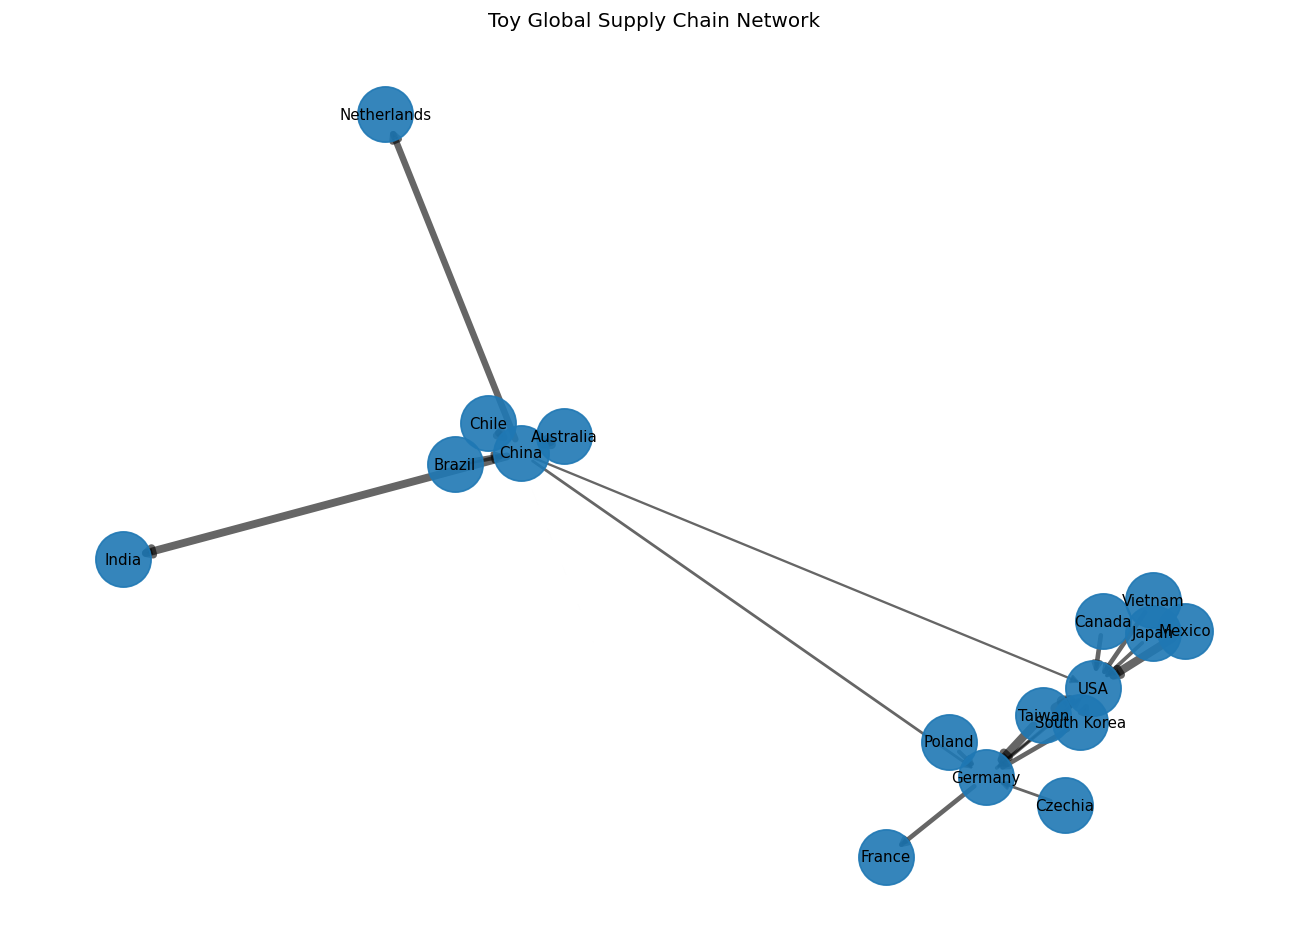

In [6]:
pos = nx.spring_layout(G, seed=42, k=1.3)

plt.figure(figsize=(11, 8))

edge_widths = [G[u][v]["weight"] / 180 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=1100, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, arrows=True, width=edge_widths, alpha=0.6)

plt.title("Toy Global Supply Chain Network")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 5 - Compute structural metrics for each country

The most important columns here are:

- `normalized_import_entropy`: how diversified a country's import base is
- `top_supplier_share`: how concentrated the largest dependency is

A country with:
- **low entropy**
- **high top supplier share**

is structurally more fragile.

In [7]:
country_table = compute_country_table(G)
country_table.round(3)

,country,n_suppliers,total_imports,import_entropy,normalized_import_entropy,top_supplier_share,n_customers,total_exports,export_entropy,normalized_export_entropy,top_customer_share
4,USA,8,4750.0,2.842,0.947,0.253,1,200.0,-0.000,0.000,1.000
6,Germany,6,2650.0,2.410,0.932,0.340,2,900.0,0.991,0.991,0.556
1,China,3,2400.0,1.555,0.981,0.417,4,2100.0,1.823,0.912,0.405
7,India,1,850.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
8,Netherlands,1,700.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
10,France,1,500.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
11,Japan,0,0.0,0.000,0.000,0.000,1,400.0,-0.000,0.000,1.000
15,Taiwan,0,0.0,0.000,0.000,0.000,2,2100.0,0.985,0.985,0.571
14,South Korea,0,0.0,0.000,0.000,0.000,2,1100.0,0.994,0.994,0.545
13,Poland,0,0.0,0.000,0.000,0.000,1,450.0,-0.000,0.000,1.000


## Step 6 - Rank countries by import fragility

This is a very simple first ranking:
- lower normalized entropy = less diversified
- higher top supplier share = more concentrated

In [8]:
fragility_view = (
    country_table[["country", "n_suppliers", "total_imports", "normalized_import_entropy", "top_supplier_share"]]
    .sort_values(["normalized_import_entropy", "top_supplier_share"], ascending=[True, False])
)

fragility_view.round(3)

,country,n_suppliers,total_imports,normalized_import_entropy,top_supplier_share
7,India,1,850.0,0.000,1.000
8,Netherlands,1,700.0,0.000,1.000
10,France,1,500.0,0.000,1.000
11,Japan,0,0.0,0.000,0.000
15,Taiwan,0,0.0,0.000,0.000
14,South Korea,0,0.0,0.000,0.000
13,Poland,0,0.0,0.000,0.000
12,Mexico,0,0.0,0.000,0.000
0,Australia,0,0.0,0.000,0.000
9,Czechia,0,0.0,0.000,0.000


## Step 7 - Inspect one node in detail

We look at Germany and the USA as example importers.

In [9]:
for country in ["Germany", "USA"]:
    profile = import_profile(G, country)
    print(f"\n=== {country} ===")
    for k, v in profile.items():
        print(f"{k}: {v}")


=== Germany ===
country: Germany
n_suppliers: 6
total_imports: 2650.0
import_entropy: 2.410433548969427
normalized_import_entropy: 0.9324829850711418
top_supplier_share: 0.33962264150943394
suppliers: ['China', 'Czechia', 'Poland', 'South Korea', 'Taiwan', 'USA']

=== USA ===
country: USA
n_suppliers: 8
total_imports: 4750.0
import_entropy: 2.841797688077187
normalized_import_entropy: 0.947265896025729
top_supplier_share: 0.25263157894736843
suppliers: ['Canada', 'China', 'Germany', 'Japan', 'Mexico', 'South Korea', 'Taiwan', 'Vietnam']


## Step 8 - Measure direct exposure to a critical exporter

One useful first question in supply-chain risk is:

**Which countries are most exposed to a given upstream source?**

Here we examine dependence on **Taiwan**.

In [10]:
taiwan_exposure = direct_exporter_exposure(df, "Taiwan")
taiwan_exposure.round(3)

,target,total_imports,imports_from_exporter,dependency_share
2,Germany,2650,900.0,0.340
5,USA,4750,1200.0,0.253
0,China,2400,0.0,0.000
1,France,500,0.0,0.000
3,India,850,0.0,0.000
4,Netherlands,700,0.0,0.000


## Step 9 - Simulate a shock

We now simulate a simple disruption scenario:

- exports from Taiwan fall by **70%**

This is intentionally simplistic, but it shows how the framework can evolve toward scenario analysis.

In [11]:
shock_exporter = "Taiwan"
shock_severity = 0.70

df_shocked = apply_export_shock(df, exporter=shock_exporter, severity=shock_severity)

G_shocked = build_trade_graph(df_shocked)
country_table_shocked = compute_country_table(G_shocked)

country_table_shocked.round(3)

,country,n_suppliers,total_imports,import_entropy,normalized_import_entropy,top_supplier_share,n_customers,total_exports,export_entropy,normalized_export_entropy,top_customer_share
4,USA,8,3910.0,2.905,0.968,0.230,1,200.0,-0.000,0.000,1.000
1,China,3,2400.0,1.555,0.981,0.417,4,2100.0,1.823,0.912,0.405
6,Germany,6,2020.0,2.517,0.974,0.248,2,900.0,0.991,0.991,0.556
7,India,1,850.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
8,Netherlands,1,700.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
10,France,1,500.0,-0.000,0.000,1.000,0,0.0,0.000,0.000,0.000
11,Japan,0,0.0,0.000,0.000,0.000,1,400.0,-0.000,0.000,1.000
15,Taiwan,0,0.0,0.000,0.000,0.000,2,630.0,0.985,0.985,0.571
14,South Korea,0,0.0,0.000,0.000,0.000,2,1100.0,0.994,0.994,0.545
13,Poland,0,0.0,0.000,0.000,0.000,1,450.0,-0.000,0.000,1.000


## Step 10 - Compare selected countries before and after the shock

We compare:

- total imports
- import entropy
- top supplier share

Note that entropy can behave in non-obvious ways after a shock:
if one dominant supplier is weakened, the remaining distribution may become more balanced, even though the country is now receiving less total volume.

That is an important lesson:
**entropy measures structural distribution, not total sufficiency**.

In the future, the project should combine:
- entropy
- concentration
- absolute volume loss
- criticality of commodity

In [12]:
comparison_rows = []

for country in ["Germany", "USA"]:
    base = import_profile(G, country)
    shocked = import_profile(G_shocked, country)

    comparison_rows.append({
        "country": country,
        "baseline_total_imports": base["total_imports"],
        "shocked_total_imports": shocked["total_imports"],
        "import_loss": base["total_imports"] - shocked["total_imports"],
        "baseline_entropy": base["import_entropy"],
        "shocked_entropy": shocked["import_entropy"],
        "baseline_top_supplier_share": base["top_supplier_share"],
        "shocked_top_supplier_share": shocked["top_supplier_share"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(3)

,country,baseline_total_imports,shocked_total_imports,import_loss,baseline_entropy,shocked_entropy,baseline_top_supplier_share,shocked_top_supplier_share
0,Germany,2650.0,2020.0,630.0,2.410,2.517,0.340,0.248
1,USA,4750.0,3910.0,840.0,2.842,2.905,0.253,0.230


## Step 11 - Visualize the impact on total imports

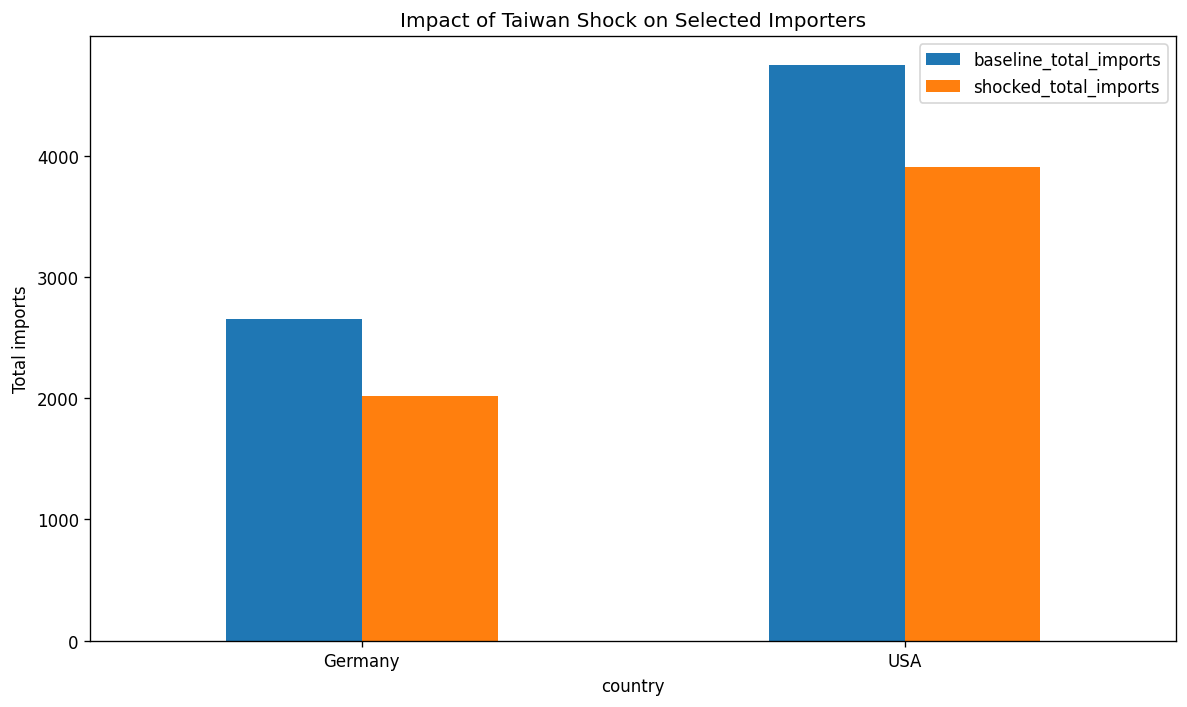

In [13]:
plot_df = comparison_df.set_index("country")[["baseline_total_imports", "shocked_total_imports"]]

plot_df.plot(kind="bar")
plt.ylabel("Total imports")
plt.title("Impact of Taiwan Shock on Selected Importers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

Even in this tiny synthetic example, the notebook already shows the core logic of the project:

1. A supply chain can be represented as a graph of dependencies
2. Entropy provides a compact way to measure diversification
3. Structural fragility is not the same as performance
4. A disruption can be studied by modifying the graph and recomputing exposure

This is the foundation of the larger idea behind Entrovia:
not just mapping supply chains, but measuring where the network is becoming brittle, concentrated, and vulnerable to shocks.

## How this notebook maps to the future codebase

This POC corresponds to four future modules:

### `data/`
- load raw trade or supplier data
- validate schemas
- clean and harmonize identifiers

### `models/`
- represent nodes, edges, and graph structure
- support countries, firms, ports, plants, routes, and commodities

### `metrics/`
- entropy
- concentration
- centrality
- robustness
- shock propagation

### `simulation/`
- export shocks
- route disruptions
- supplier failures
- scenario comparison

In other words, this notebook is not just an analysis.
It is the first executable sketch of the future project architecture.